# Student Dropout Data

## Import dataset

In [ ]:
import kagglehub
import pandas as pd
import os
from matplotlib import pyplot as plt
import seaborn as sns

# Download latest version
path = kagglehub.dataset_download("meharshanali/student-dropout-prediction-dataset")

print("Path to dataset files:", path)
files = os.listdir(path)
df = pd.read_csv(os.path.join(path, files[0]))

Using Colab cache for faster access to the 'student-dropout-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/student-dropout-prediction-dataset


## Basic Statistics

In [ ]:
df.head().style.set_table_styles([
    {
        'selector': 'th.col_heading',
        'props': [
            ('writing-mode', 'vertical-rl'),
            ('transform', 'rotate(180deg)'),
            ('height', '130px'),
            ('max-height', '100px'),
            ('vertical-align', 'middle'),
            ('text-align', 'left'),
            ('white-space', 'nowrap'),
            ('padding', '10px 5px'),
            ('font-size', '7pt'),
            ('border', '1px solid black')
        ]
    },
    {
        'selector': 'td',
        'props': [
            ('font-size', '8pt'),
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('min-width', '40px')
        ]
    }
])

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.100000,Male,25000.000000,Yes,3.360000,86.100000,2,20.400000,Yes,No,5.500000,0.960000,0.900000,0.900000,Year 1,Arts,High School,0
1,2,20.700000,Male,25000.000000,Yes,4.300000,68.000000,2,44.000000,No,No,6.800000,1.280000,1.200000,1.190000,Year 3,Engineering,Bachelor,1
2,3,22.400000,Male,40183.000000,Yes,4.400000,70.900000,0,48.900000,Yes,No,5.500000,1.680000,1.320000,1.320000,Year 1,Arts,Master,0
3,4,24.400000,Male,nan,Yes,nan,82.200000,2,38.600000,No,No,nan,1.780000,1.770000,1.770000,Year 1,CS,High School,1
4,5,20.500000,Female,25319.000000,Yes,4.190000,75.700000,1,23.000000,No,No,7.000000,1.480000,0.910000,0.870000,Year 4,Business,Bachelor,0


In [ ]:

demographics = [
    "Student_ID", "Age", "Gender", "Family_Income",
    "Internet_Access", "Parental_Education"
]
df_demo = pd.DataFrame(demographics, columns=["Personal Information"])

academic = [
    "GPA", "Semester_GPA", "CGPA", "Semester", "Department"
]
df_acad = pd.DataFrame(academic, columns=["Academic Performance"])

behavior = [
    "Study_Hours_per_Day", "Attendance_Rate", "Assignment_Delay_Days",
    "Travel_Time_Minutes", "Part_Time_Job", "Scholarship", "Stress_Index"
]
df_beh = pd.DataFrame(behavior, columns=["Behavior"])

def style_table(df, color):
    return df.style.set_properties(**{
        'text-align': 'left', 'font-size': '11pt', 'border': '1px solid #ddd'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', color), ('color', 'white'), ('text-align', 'center')]}
    ]).hide(axis='index')
from IPython.display import display, HTML

def get_style_html(df, color):
    styled = df.style.set_properties(**{
        'text-align': 'left',
        'font-size': '10pt',
        'border': '1px solid #ddd',
        'padding': '8px'
    }).set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', color),
                ('color', 'white'),
                ('text-align', 'center'),
                ('padding', '10px')
            ]
        }
    ]).hide(axis='index')

    return f"<div style='display: inline-block; vertical-align: top; margin-right: 3px;'>{styled.to_html()}</div>"

full_html = (
    get_style_html(df_demo, '#2c3e50') +
    get_style_html(df_acad, '#2c3e50') +
    get_style_html(df_beh, '#2c3e50')
)

display(HTML(full_html))

Personal Information
Student_ID
Age
Gender
Family_Income
Internet_Access
Parental_Education
Academic Performance
GPA
Semester_GPA
CGPA


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [ ]:
import pandas as pd

info_df = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.count().values,
    "Dtype": df.dtypes.values,
    "Null Values": df.isnull().sum().values,
    "% Missing": (df.isnull().sum().values / len(df) * 100).round(2)
})

styled_info = info_df.style.set_properties(**{
    'text-align': 'center',
    'font-size': '7pt',
    'border': '1px solid #eee',
    'padding': '3px'
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#34495e'),
        ('color', 'white'),
        ('text-align', 'center'),
        ('font-size', '7pt')

    ]},
    {'selector': 'td', 'props': [('vertical-align', 'middle')]}
]).hide(axis='index')

def highlight_nulls(s):
    return ['background-color: #ffedcc' if v > 0 else '' for v in s]
display(styled_info.apply(highlight_nulls, subset=['Null Values']))

Column,Non-Null Count,Dtype,Null Values,% Missing
Student_ID,10000,int64,0,0.000000
Age,10000,float64,0,0.000000
Gender,10000,object,0,0.000000
Family_Income,9500,float64,500,5.000000
Internet_Access,10000,object,0,0.000000
Study_Hours_per_Day,9500,float64,500,5.000000
Attendance_Rate,10000,float64,0,0.000000
Assignment_Delay_Days,10000,int64,0,0.000000
Travel_Time_Minutes,10000,float64,0,0.000000
Part_Time_Job,10000,object,0,0.000000


In [ ]:
df['Dropout'] = df['Dropout'].map({0: 'No', 1: 'Yes'})
print(df['Dropout'].value_counts())

Dropout
No     7646
Yes    2354
Name: count, dtype: int64


## Feature importance

คอลัมน์ที่นำไปทำ Heatmap: ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']


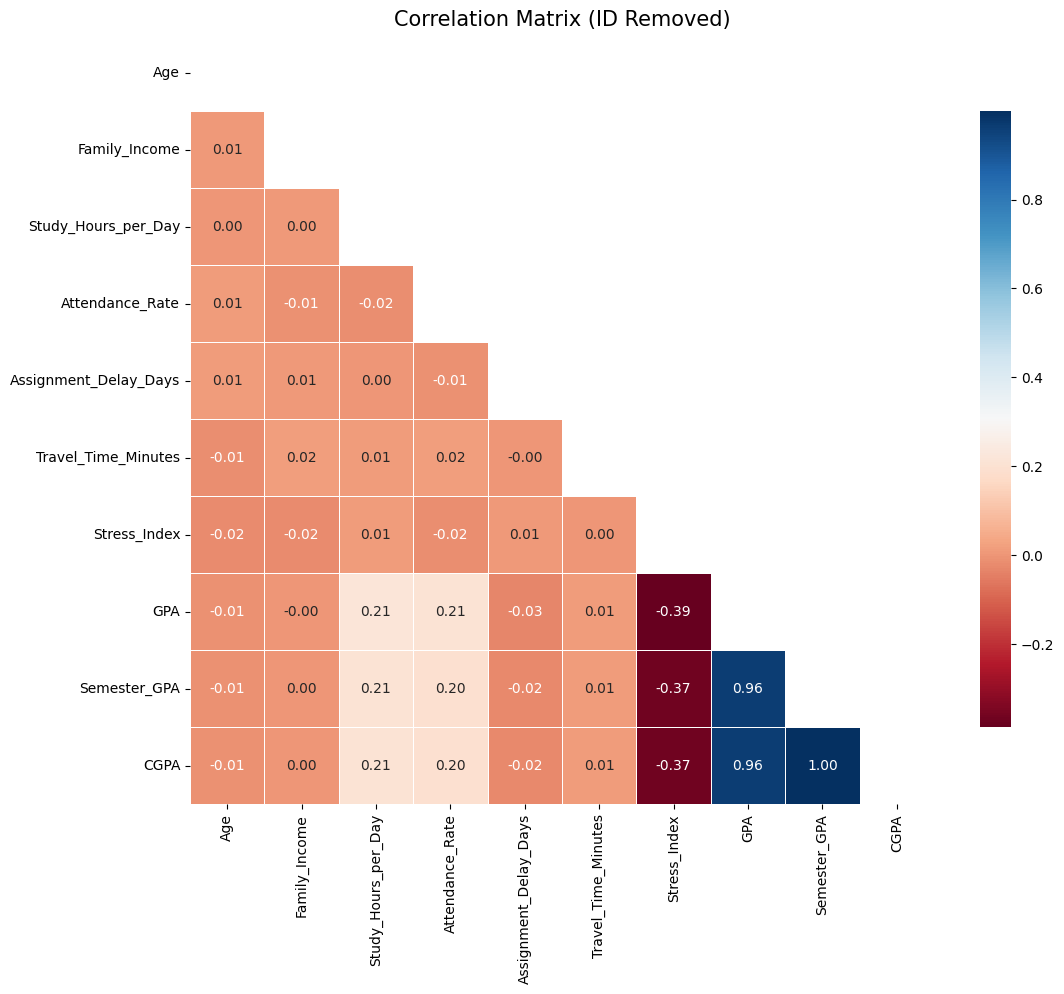

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = df.select_dtypes(include=['number'])

cols_to_drop = [col for col in df_numeric.columns if 'id' in col.lower()]
df_numeric = df_numeric.drop(columns=cols_to_drop)

corr_matrix = df_numeric.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='RdBu',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)
plt.title('Correlation Matrix (ID Removed)', fontsize=15)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def get_cramers_v(var1, var2):
    crosstab = pd.crosstab(var1, var2)
    chi2 = chi2_contingency(crosstab)[0]
    n = crosstab.sum().sum()
    phi2 = chi2 / n
    r, k = crosstab.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

object_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Dropout' not in object_cols:
    object_cols.append('Dropout')

v_results = {}
for col in object_cols:
    if col != 'Dropout':
        v_results[col] = get_cramers_v(df[col], df['Dropout'])

v_df = pd.DataFrame.from_dict(v_results, orient='index', columns=['Dropout'])
v_df = v_df.sort_values(by='Dropout', ascending=False)


styled_v_df = v_df.style.background_gradient(cmap='YlGnBu')\
                   .format("{:.2f}")\
                   .set_table_styles([
                       {'selector': 'th', 'props': [('font-size', '10pt')]}, # ขนาดหัวตาราง
                       {'selector': 'td', 'props': [('font-size', '9pt')]}   # ขนาดตัวเลข/ชื่อฟีเจอร์
                   ])

styled_v_df

,Dropout
Internet_Access,0.04
Part_Time_Job,0.04
Parental_Education,0.01
Semester,0.01
Gender,0.00
Scholarship,0.00
Department,0.00


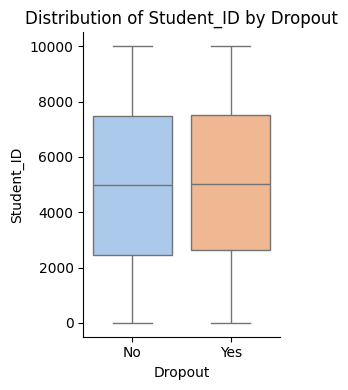

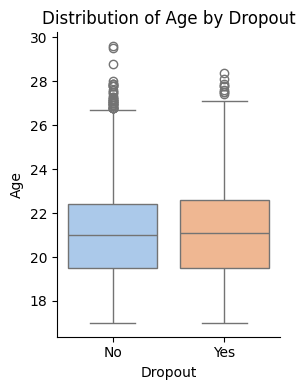

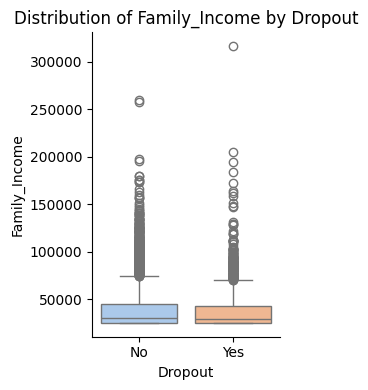

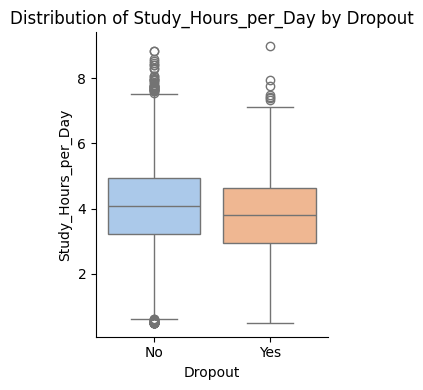

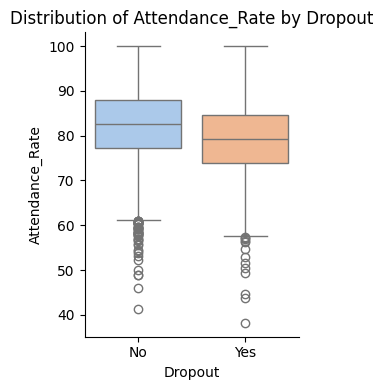

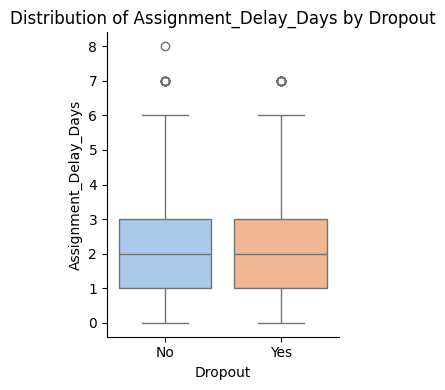

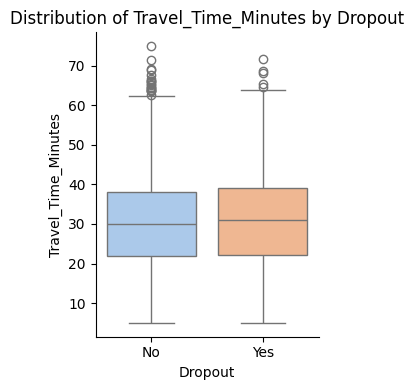

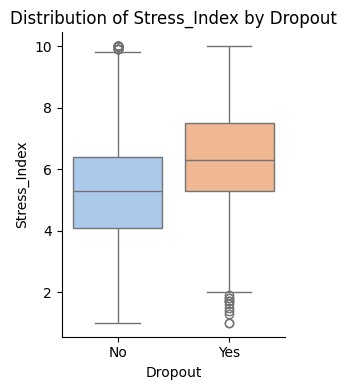

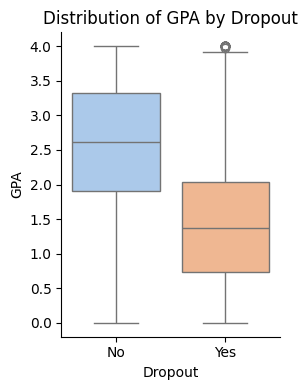

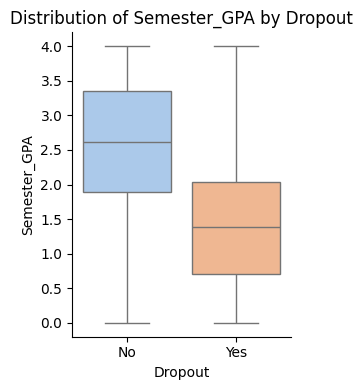

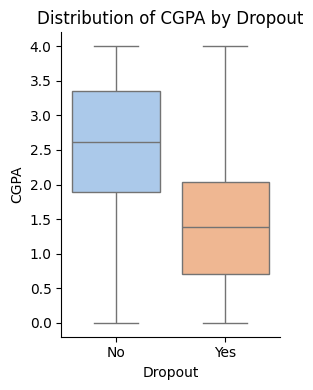

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

target_col = 'Dropout'

features = df.select_dtypes(include=['number']).columns.tolist()
if target_col in features:
    features.remove(target_col)

for feature in features:
    plt.figure(figsize=(3, 4))
    sns.boxplot(
        data=df,
        x=target_col,
        y=feature,
        palette="pastel",
        hue=target_col,
        legend=False
    )

    plt.title(f"Distribution of {feature} by {target_col}", fontsize=12)
    plt.xlabel(target_col)
    plt.ylabel(feature)

    sns.despine()
    plt.tight_layout()
    plt.show()

## Handling Missing value

In [ ]:
original_rows = len(df)
remaining_rows = len(df.dropna())
loss_percent = ((original_rows - remaining_rows) / original_rows) * 100
print(f"ถ้าลบทิ้งทั้งหมด ข้อมูลจะหายไป: {loss_percent:.2f}%")
print(f"{(original_rows - remaining_rows)}")

ถ้าลบทิ้งทั้งหมด ข้อมูลจะหายไป: 9.80%
980


In [ ]:
df = df.dropna().copy()

In [ ]:
cols_to_encode = ['Internet_Access', 'Part_Time_Job', 'Semester',
                  'Parental_Education', 'Scholarship', 'Gender', 'Department']

df = pd.get_dummies(df, columns=cols_to_encode)

target = df['Dropout']
X = df.drop(columns=['Dropout'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9020 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      9020 non-null   int64  
 1   Age                             9020 non-null   float64
 2   Family_Income                   9020 non-null   float64
 3   Study_Hours_per_Day             9020 non-null   float64
 4   Attendance_Rate                 9020 non-null   float64
 5   Assignment_Delay_Days           9020 non-null   int64  
 6   Travel_Time_Minutes             9020 non-null   float64
 7   Stress_Index                    9020 non-null   float64
 8   GPA                             9020 non-null   float64
 9   Semester_GPA                    9020 non-null   float64
 10  CGPA                            9020 non-null   float64
 11  Dropout                         9020 non-null   object 
 12  Internet_Access_No              9020 no

In [ ]:
df1 = df.copy()

# Train KNN Model

## Without PCA

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df = df.drop(columns=['Student_ID'])
y = df['Dropout'].values
X = df.drop(columns=['Dropout']).values


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=7)
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
y_pred.shape

(1353,)

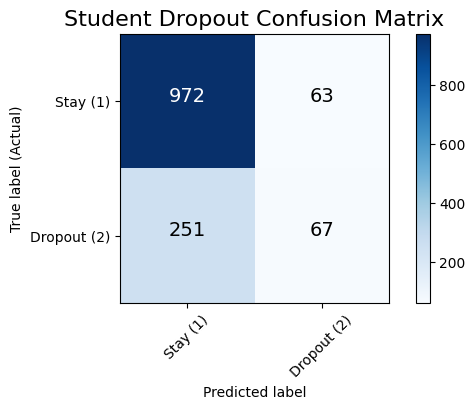

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(6, 4))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, size=16)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 size=14)

    plt.tight_layout()
    plt.ylabel('True label (Actual)')
    plt.xlabel('Predicted label')
    plt.show()

class_names = ['Stay (1)', 'Dropout (2)']

cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, classes=class_names, title='Student Dropout Confusion Matrix')

In [ ]:
print(df['Dropout'].unique())
print(df['Dropout'].value_counts())

['No' 'Yes']
Dropout
No     6902
Yes    2118
Name: count, dtype: int64


## Applying PCA

In [ ]:
df = df1.copy().drop(columns=['Student_ID'])
y = df['Dropout'].values
X = df.drop(columns=['Dropout']).values


In [ ]:
from sklearn.decomposition import PCA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=7)
classifier.fit(X_train_pca, y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
y_pred = classifier.predict(X_test_pca)

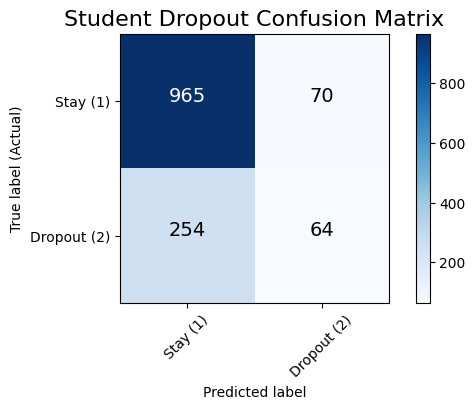

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(6, 4))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, size=16)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 size=14)

    plt.tight_layout()
    plt.ylabel('True label (Actual)')
    plt.xlabel('Predicted label')
    plt.show()

class_names = ['Stay (1)', 'Dropout (2)']

cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, classes=class_names, title='Student Dropout Confusion Matrix')

In [ ]:
error = []

for i in range(1, 10):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_pca, y_train)
    pred_i = knn.predict(X_test_pca)
    error.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Mean Error')

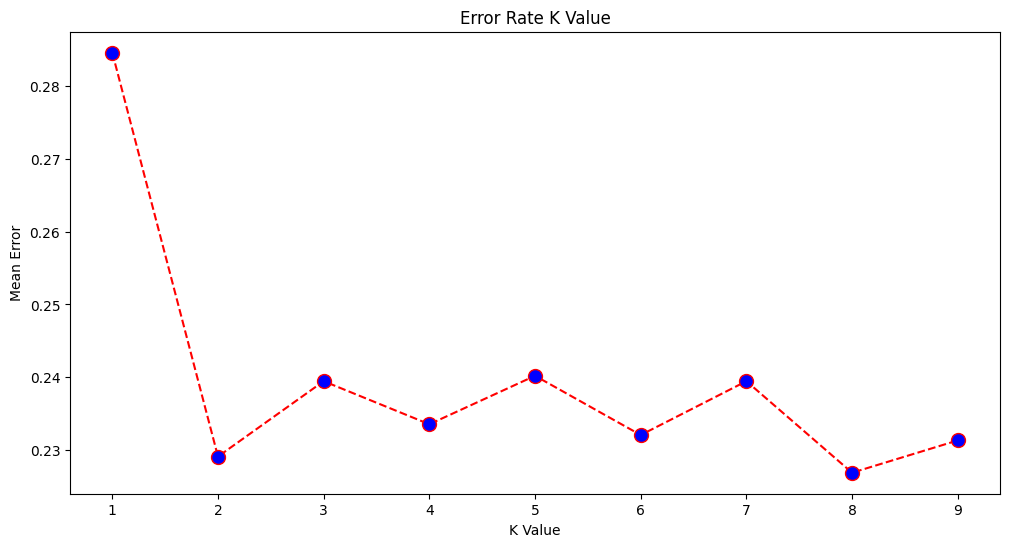

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 10), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')


# Train Hierachical Clustering Model

## Feature Engineering

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = df1.copy()
df['GPA_Trend'] = df['Semester_GPA'] - df['CGPA']

df['Academic_Responsibility'] = df['Attendance_Rate'] - df['Assignment_Delay_Days']

df['Daily_Load'] = df['Study_Hours_per_Day'] + (df['Travel_Time_Minutes'] / 60)

print(df[['GPA_Trend', 'Academic_Responsibility', 'Daily_Load']].head())

   GPA_Trend  Academic_Responsibility  Daily_Load
0       0.00                     84.1    3.700000
1       0.01                     66.0    5.033333
2       0.00                     70.9    5.215000
4       0.04                     74.7    4.573333
6      -0.11                     77.2    3.623333


In [ ]:
X = df.drop(columns=['Dropout', 'Student_ID'])

In [ ]:
cols_to_drop = [
    'Semester_GPA', 'CGPA',
    'Attendance_Rate', 'Assignment_Delay_Days',
    'Study_Hours_per_Day', 'Travel_Time_Minutes', 'Student_ID'
]

df = df.drop(columns=cols_to_drop)

print("Remaining columns:", df.columns.tolist())
df.head()

Remaining columns: ['Age', 'Family_Income', 'Stress_Index', 'GPA', 'Dropout', 'Internet_Access_No', 'Internet_Access_Yes', 'Part_Time_Job_No', 'Part_Time_Job_Yes', 'Semester_Year 1', 'Semester_Year 2', 'Semester_Year 3', 'Semester_Year 4', 'Parental_Education_Bachelor', 'Parental_Education_High School', 'Parental_Education_Master', 'Parental_Education_PhD', 'Scholarship_No', 'Scholarship_Yes', 'Gender_Female', 'Gender_Male', 'Department_Arts', 'Department_Business', 'Department_CS', 'Department_Engineering', 'Department_Science', 'GPA_Trend', 'Academic_Responsibility', 'Daily_Load']


,Age,Family_Income,Stress_Index,GPA,Dropout,Internet_Access_No,Internet_Access_Yes,Part_Time_Job_No,Part_Time_Job_Yes,Semester_Year 1,...,Gender_Female,Gender_Male,Department_Arts,Department_Business,Department_CS,Department_Engineering,Department_Science,GPA_Trend,Academic_Responsibility,Daily_Load
0,22.1,25000.0,5.5,0.96,No,False,True,False,True,True,...,False,True,True,False,False,False,False,0.00,84.1,3.700000
1,20.7,25000.0,6.8,1.28,Yes,False,True,True,False,False,...,False,True,False,False,False,True,False,0.01,66.0,5.033333
2,22.4,40183.0,5.5,1.68,No,False,True,False,True,True,...,False,True,True,False,False,False,False,0.00,70.9,5.215000
4,20.5,25319.0,7.0,1.48,No,False,True,True,False,False,...,True,False,False,True,False,False,False,0.04,74.7,4.573333
6,24.5,25000.0,7.3,0.64,No,False,True,False,True,False,...,False,True,False,False,True,False,False,-0.11,77.2,3.623333


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9020 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             9020 non-null   float64
 1   Family_Income                   9020 non-null   float64
 2   Stress_Index                    9020 non-null   float64
 3   GPA                             9020 non-null   float64
 4   Dropout                         9020 non-null   object 
 5   Internet_Access_No              9020 non-null   bool   
 6   Internet_Access_Yes             9020 non-null   bool   
 7   Part_Time_Job_No                9020 non-null   bool   
 8   Part_Time_Job_Yes               9020 non-null   bool   
 9   Semester_Year 1                 9020 non-null   bool   
 10  Semester_Year 2                 9020 non-null   bool   
 11  Semester_Year 3                 9020 non-null   bool   
 12  Semester_Year 4                 9020 no

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_numeric = le.fit_transform(y_train)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
pca = PCA(0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=2)
y_hc = hc.fit_predict(X_train_pca)

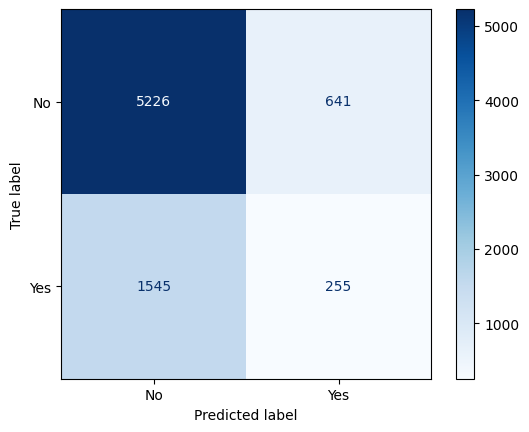

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_train_numeric, y_hc)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')

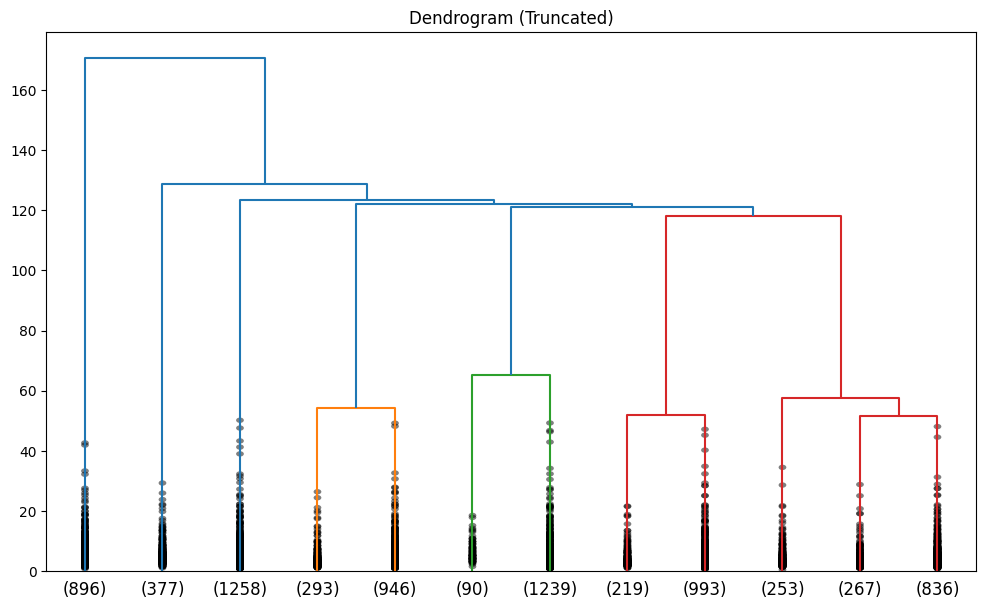

In [ ]:
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(12, 7))
dendrogram = sch.dendrogram(
    sch.linkage(X_train_pca, method='ward'),
    truncate_mode='lastp',
    p=12,
    show_contracted=True
)
plt.title("Dendrogram (Truncated)")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, adjusted_rand_score

print(classification_report(y_train_numeric, y_hc))

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train_numeric, y_hc):.2f}")

              precision    recall  f1-score   support

           0       0.77      0.89      0.83      5867
           1       0.28      0.14      0.19      1800

    accuracy                           0.71      7667
   macro avg       0.53      0.52      0.51      7667
weighted avg       0.66      0.71      0.68      7667

Adjusted Rand Index: 0.02


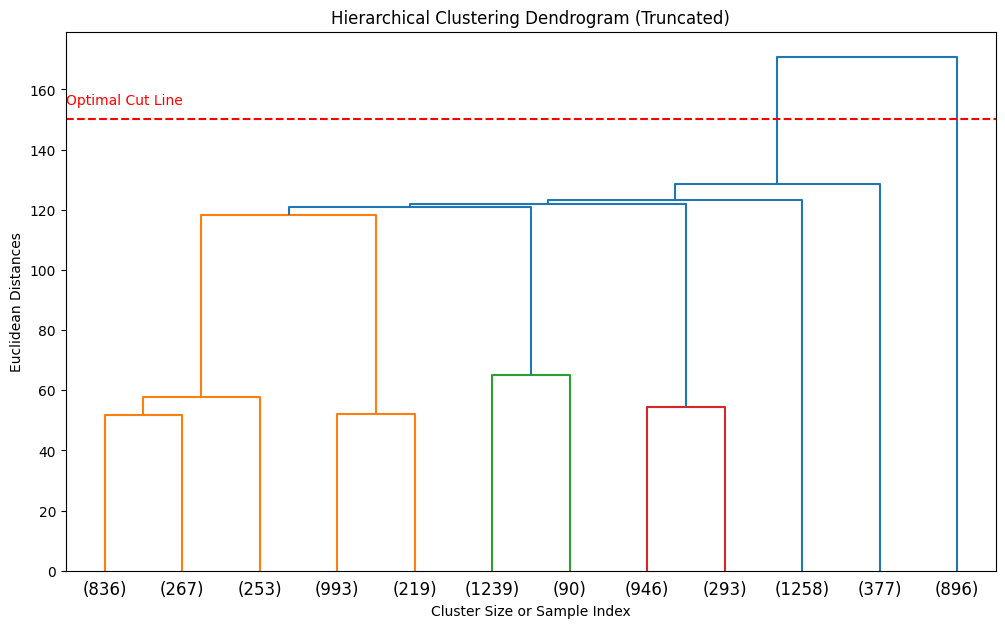

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_train_pca, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(linked,
            orientation='top',
            labels=None,
            distance_sort='descending',
            show_leaf_counts=True,
            truncate_mode='lastp',
            p=12)

plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Cluster Size or Sample Index')
plt.ylabel('Euclidean Distances')

plt.axhline(y=150, color='r', linestyle='--')
plt.annotate('Optimal Cut Line', xy=(0, 155), color='red')

plt.show()

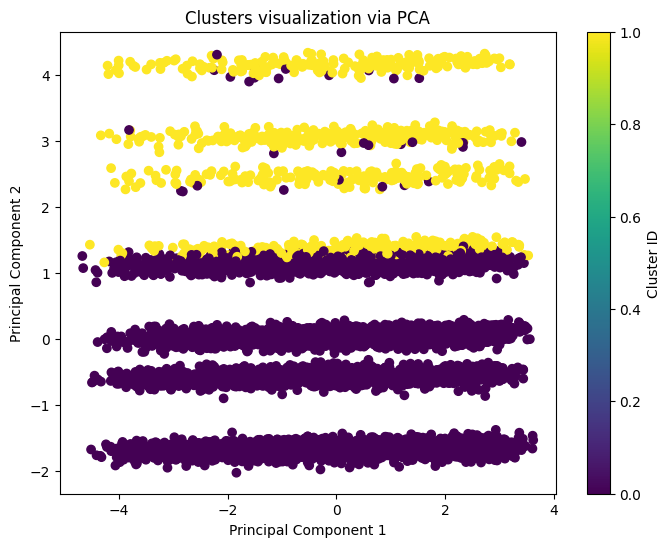

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_hc, cmap='viridis')
plt.title('Clusters visualization via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster ID')
plt.show()